# 6 · Fatigue

MIL-HDBK-5J S-N curves, rainflow counting, and Miner's rule on a synthetic flight spectrum.
Theory: [docs/fatigue.md](../docs/fatigue.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from structures import plotting as P

P.use_style()
DEG = np.pi / 180
MPA = 1e6
from structures.fatigue import (handbook_curve, count_cycles, histogram, flight_history,
                                miner_damage, blocks_to_failure)
from structures.materials import KSI

In [2]:
astm = [-2, 1, -3, 5, -1, 3, -4, 4, -2]          # ASTM E1049 example
for c in count_cycles(astm):
    print(f"range {c.range:g}, mean {c.mean:+.1f}, count {c.count}")
print("histogram:", histogram(count_cycles(astm)))

range 3, mean -0.5, count 0.5
range 4, mean -1.0, count 0.5
range 4, mean +1.0, count 1.0
range 8, mean +1.0, count 0.5
range 9, mean +0.5, count 0.5
range 8, mean +0.0, count 0.5
range 6, mean +1.0, count 0.5
histogram: [(3.0, 0.5), (4.0, 1.5), (6.0, 0.5), (8.0, 1.0), (9.0, 0.5)]


In [3]:
c = handbook_curve("2024-T3_Kt2")
print(c.name, c.source, f"A1..A4 = {c.A1}, {c.A2}, {c.A3}, {c.A4} ksi")
for R in (-1, 0, 0.5):
    print(f"R = {R:+.1f}: Smax for 1e5 cycles = {c.max_stress_for_life(1e5, R)/KSI:.1f} ksi")

2024-T3 Kt = 2.0 [5J-F3.2.3.1.8(g)] A1..A4 = 9.2, -3.33, 0.68, 12.3 ksi
R = -1.0: Smax for 1e5 cycles = 19.1 ksi
R = +0.0: Smax for 1e5 cycles = 30.5 ksi
R = +0.5: Smax for 1e5 cycles = 48.9 ksi


20007 cycles, damage per 500 flights = 2.373e-03, median life = 210,691 flights


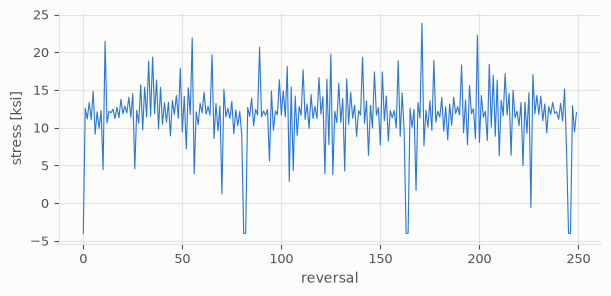

In [4]:
hist = flight_history(500, s_1g=12 * KSI, s_ground=-4 * KSI, beta=2.5 * KSI, seed=11)
cycles = count_cycles(hist)
D = miner_damage(cycles, c.life_from_amplitude)
print(f"{len(cycles)} cycles, damage per 500 flights = {D:.3e}, "
      f"median life = {blocks_to_failure(D) * 500:,.0f} flights")
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(hist[:250] / KSI, lw=0.8); ax.set_ylabel("stress [ksi]"); ax.set_xlabel("reversal");

That is a median life with no scatter factor. Certification divides it by a scatter factor and backs it up with crack-growth-based inspections.